In [367]:
from efgpnd import NUFFT, get_xis, _cmplx
import torch

In [368]:


# --- Parameters ---
n = 100  # Number of points
d = 2  # Dimensionality of the input space
true_length_scale =0.1
true_variance = 1
true_noise_variance = 0.2
dtype = torch.float64  # Use float64 as in the original example
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
print(f"Using device: {device}")

# --- Generate Input Points ---
# Generate random points in d-dimensional space from -1 to 1
x = torch.rand(n, d, dtype=dtype, device=device) * 2 - 1

kernel_type = "SquaredExponential"

print(f'x.shape: {x.shape}')

Using device: cpu
x.shape: torch.Size([100, 2])


In [369]:
from kernels.squared_exponential import SquaredExponential
lengthscale = 0.1
variance = 1
kernel = SquaredExponential(dimension=d, init_lengthscale=lengthscale, init_variance=variance)
eps = 1e-4
nufft_eps = 1e-4

In [370]:
device = x.device
rdtype = x.dtype  # Use input data's dtype instead of hardcoding
cdtype = _cmplx(rdtype)
# Get domain size (L)

L = torch.max(torch.max(x, dim=0).values - torch.min(x, dim=0).values)
if L <= 1e-9:
    L = torch.tensor(1.0, device=device, dtype=rdtype)

# Get frequency grid
xis_1d, h_float, mtot = get_xis(
    kernel_obj=kernel, 
    eps=eps, 
    L=L.item(), 
    use_integral=True, 
    l2scaled=False
)
h = torch.tensor(h_float, device=device, dtype=rdtype)
xis_1d = xis_1d.to(device=device, dtype=rdtype)

# Create n-dimensional grid
grids = torch.meshgrid(*(xis_1d for _ in range(d)), indexing="ij")
xis = torch.stack(grids, dim=-1).view(-1, d)

# Store h_float as an attribute for later use
xis.h_float = h_float

# NUFFT Setup for training points
OUT = (mtot,) * d
xcen = torch.zeros(d, device=device, dtype=rdtype)

# Compute spectral density values
spectral_vals = kernel.spectral_density(xis).to(dtype=cdtype)
ws = torch.sqrt(spectral_vals * (h ** d))
ws = ws.to(dtype=cdtype)

# Setup for training points - use our NUFFT class
nufft_op = NUFFT(x, xcen, h, nufft_eps, cdtype=cdtype, device=device)
fwd = lambda fk: nufft_op.type2(fk, out_shape=OUT)                # F apply:  uniform → nonuniform

print(ws)

tensor([4.6962e-07+0.j, 8.8250e-07+0.j, 1.6028e-06+0.j,  ..., 1.6028e-06+0.j,
        8.8250e-07+0.j, 4.6962e-07+0.j], dtype=torch.complex128)


## Sampling from a GP prior via EFGP spectral representation

Given a stationary kernel $k$ with spectral density $\hat{k}$, we approximate a GP draw on an equispaced frequency grid $\mathcal{J}_m = \{-m, \ldots, m\}^d$ with spacing $h$. We present two equivalent methods.

### Method 1: Conjugate-symmetric complex normals (real-valued output)

$$\tilde{f}(x) = \sum_{j \in \mathcal{J}_m} \sqrt{h^d \hat{k}(hj)}\; e^{2\pi i \langle hj, x \rangle}\; Z_j$$

where $Z_j = \alpha_j + i\beta_j$ with $\alpha_j, \beta_j \sim \mathcal{N}(0, 1/2)$ independent, and $Z_{-j} = \bar{Z}_j$.

**Why the covariance is correct.** Since $Z_{-j} = \bar{Z}_j$, we have $\mathbb{E}[Z_j \bar{Z}_k] = \delta_{j,k}$ and $\mathbb{E}[Z_j Z_k] = 0$ (even for $k = -j$, since $\mathbb{E}[Z_j^2] = \mathbb{E}[\alpha_j^2 - \beta_j^2] + 2i\mathbb{E}[\alpha_j \beta_j] = \tfrac{1}{2} - \tfrac{1}{2} + 0 = 0$). Therefore:

$$\mathbb{E}[\tilde{f}(x)\tilde{f}(x')] = \sum_{j,k} w_j w_k \, e^{2\pi i \langle hj,x\rangle} e^{-2\pi i \langle hk,x'\rangle} \underbrace{\mathbb{E}[Z_j \bar{Z}_k]}_{=\,\delta_{j,k}} = \sum_j h^d \hat{k}(hj) \, e^{2\pi i \langle hj, x - x'\rangle} \approx k(x - x').$$

The conjugate symmetry ensures $\tilde{f}$ is exactly real-valued, so this equals $\mathbb{E}[\tilde{f}(x)\tilde{f}(x')]$. This method allows comparison with a Cholesky ground truth on the same draw, since the underlying white noise can be extracted.

### Method 2: Independent complex normals + $\sqrt{2}\,\text{Re}[\cdot]$ (simpler)

$$\tilde{f}(x) = \sqrt{2}\;\text{Re}\left[\sum_{j \in \mathcal{J}_m} \sqrt{h^d \hat{k}(hj)}\; e^{2\pi i \langle hj, x \rangle}\; Z_j\right]$$

where $Z_j \sim \mathcal{CN}(0, 1)$ are i.i.d. (no conjugate symmetry).

**Why the covariance is correct.** Let $g(x) = \sum_j w_j Z_j e^{2\pi i \langle hj, x\rangle}$ with i.i.d. $Z_j \sim \mathcal{CN}(0,1)$. Since the $Z_j$ are independent:

$$\mathbb{E}[g(x)\overline{g(x')}] = \sum_j h^d \hat{k}(hj)\, e^{2\pi i \langle hj, x-x'\rangle} \approx k(x-x')$$

and crucially $\mathbb{E}[g(x) g(x')] = 0$ (because $\mathbb{E}[Z_j Z_k] = 0$ for proper complex normals). Then for $\tilde{f} = \sqrt{2}\,\text{Re}[g]$:

$$\mathbb{E}[\tilde{f}(x)\tilde{f}(x')] = 2\,\mathbb{E}[\text{Re}[g(x)]\text{Re}[g(x')]] = 2 \cdot \tfrac{1}{2}\text{Re}\!\left[\mathbb{E}[g(x)\overline{g(x')}] + \underbrace{\mathbb{E}[g(x)g(x')]}_{=\,0}\right] = \text{Re}[k(x-x')] = k(x-x').$$

The key identity is $\mathbb{E}[\text{Re}[g]\text{Re}[g']] = \tfrac{1}{2}\text{Re}[\mathbb{E}[g\bar{g}'] + \mathbb{E}[gg']]$, and the second term vanishes for proper complex normals. This method is simpler (no conjugate map) but cannot be matched to a Cholesky ground truth on the same draw.

In [371]:
xis.shape

torch.Size([1521, 2])

In [372]:
# Build conjugate index map: pair frequency j with -j in Z^d
# xis_1d = [-hm*h, ..., 0, ..., hm*h], so position p -> position (mtot-1-p) is negation
M = len(ws)
indices = torch.arange(M)
remaining = indices.clone()
conj_flat = torch.zeros(M, dtype=torch.long)
for dim in range(d):
    stride = mtot ** (d - 1 - dim)
    mi = remaining // stride
    remaining = remaining % stride
    conj_flat += (mtot - 1 - mi) * stride

# Verify: xis[conj_flat] should equal -xis
print(f'Conjugate map verification: max|xis[conj] + xis| = {(xis[conj_flat] + xis).abs().max():.2e}')

is_self_conj = (indices == conj_flat)
is_primary = indices < conj_flat

# Generate conjugate-symmetric complex normal: Z_{-j} = conj(Z_j)
# Per your notes: Z_j = alpha_j + i*beta_j, alpha_j,beta_j ~ N(0, 1/2)
# so E[|Z_j|^2] = 1.  For j=0, Z_0 ~ N(0,1) real.
z = torch.zeros(M, dtype=cdtype, device=device)
z_real = torch.randn(M, device=device, dtype=rdtype)
z_imag = torch.randn(M, device=device, dtype=rdtype)

# Self-conjugate (j=0): real N(0,1)
z[is_self_conj] = z_real[is_self_conj].to(cdtype)
# Primary half: Z_j = (a + ib)/sqrt(2), so each part has variance 1/2
z[is_primary] = ((z_real[is_primary] + 1j * z_imag[is_primary]) / (2**0.5)).to(cdtype)
# Secondary half: Z_{-j} = conj(Z_j)
z[~is_primary & ~is_self_conj] = z[conj_flat[~is_primary & ~is_self_conj]].conj()

print(f'z.shape: {z.shape}')
print(f'Conjugate symmetry check: {torch.allclose(z[conj_flat], z.conj())}')

Conjugate map verification: max|xis[conj] + xis| = 0.00e+00
z.shape: torch.Size([1521])
Conjugate symmetry check: True


### Method 2: Independent complex normals + $\sqrt{2}\,\text{Re}[\cdot]$

In [373]:
M = len(ws)
z2_real = torch.randn(M, device=device, dtype=rdtype)
z2_imag = torch.randn(M, device=device, dtype=rdtype)
z2 = ((z2_real + 1j * z2_imag) / (2**0.5)).to(cdtype)  # CN(0,1)

sample_method2 = (2**0.5) * fwd(ws * z2).real
print(f'Method 2 sample std: {sample_method2.std():.4f}')

Method 2 sample std: 1.0312


### Method 1: Conjugate-symmetric $Z_j$

Method 1 std: 1.0567
Method 2 std: 1.0443
Cholesky std: 1.0563


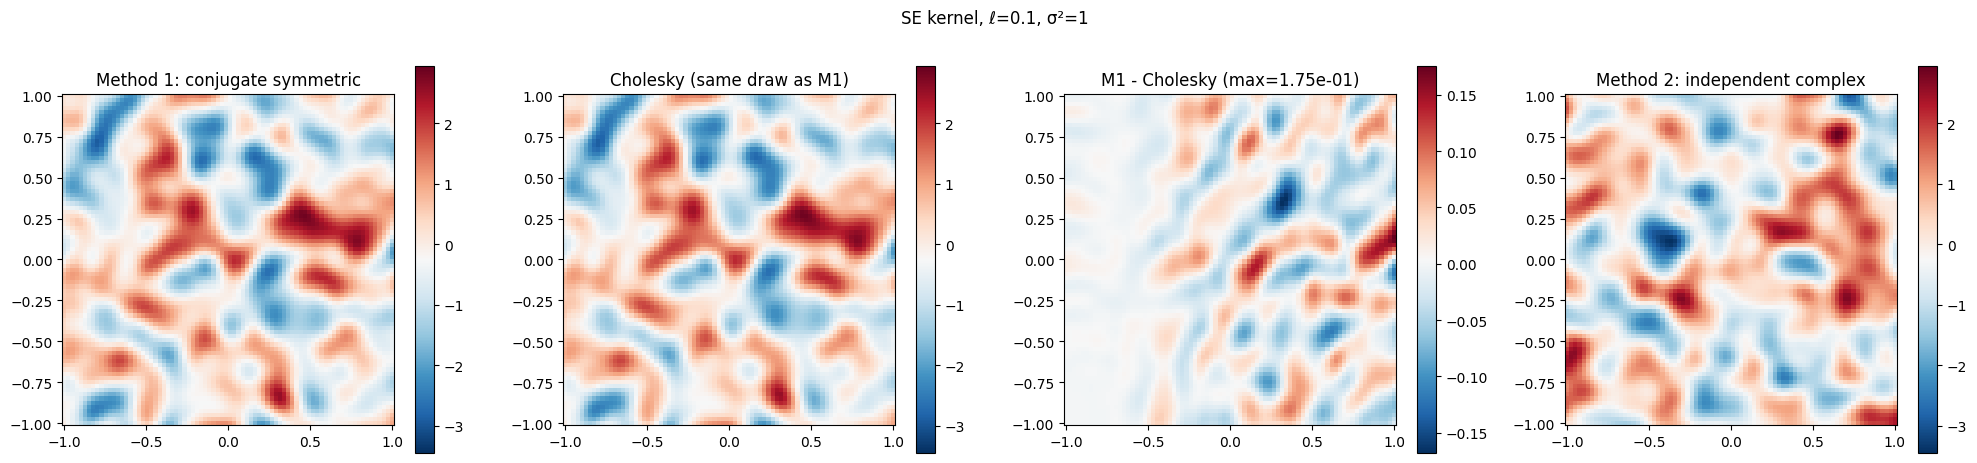

In [374]:
import matplotlib.pyplot as plt

# Dense regular grid — small enough for Cholesky
ngrid = 80
g1 = torch.linspace(-1, 1, ngrid, dtype=rdtype, device=device)
g2 = torch.linspace(-1, 1, ngrid, dtype=rdtype, device=device)
xx, yy = torch.meshgrid(g1, g2, indexing='ij')
x_grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=-1)
N = x_grid.shape[0]

nufft_grid = NUFFT(x_grid, xcen, h, nufft_eps, cdtype=cdtype, device=device)
fwd_grid = lambda fk: nufft_grid.type2(fk, out_shape=OUT)

# --- Method 1 sample on grid ---
sample_m1 = fwd_grid(ws * z).real

# --- Method 2 sample on grid ---
sample_m2 = (2**0.5) * fwd_grid(ws * z2).real

# --- Cholesky ground truth matched to Method 1 ---
# Build explicit F matrix to extract white noise from Method 1
phases = 2 * torch.pi * (x_grid @ xis.T)
F = torch.exp(1j * phases).to(cdtype)
sample_m1_explicit = (F @ (ws * z)).real

# True Gram and its Cholesky
dists_sq = torch.cdist(x_grid, x_grid).pow(2)
K = variance * torch.exp(-0.5 * dists_sq / lengthscale**2)
K_jitter = K + 1e-6 * torch.eye(N, dtype=rdtype, device=device)
L = torch.linalg.cholesky(K_jitter)

# Approximate covariance Phi = Re[F diag(|ws|^2) F*]
Phi = (F * (ws.abs()**2).unsqueeze(0)) @ F.conj().T
Phi = Phi.real + 1e-6 * torch.eye(N, dtype=rdtype, device=device)
L_phi = torch.linalg.cholesky(Phi)

# Extract white noise and push through true Cholesky
alpha = torch.linalg.solve_triangular(L_phi, sample_m1_explicit.unsqueeze(-1), upper=False).squeeze(-1)
sample_chol = (L @ alpha.unsqueeze(-1)).squeeze(-1)

print(f'Method 1 std: {sample_m1.std():.4f}')
print(f'Method 2 std: {sample_m2.std():.4f}')
print(f'Cholesky std: {sample_chol.std():.4f}')

# --- Plot ---
vmin = min(sample_m1.min().item(), sample_m2.min().item(), sample_chol.min().item())
vmax = max(sample_m1.max().item(), sample_m2.max().item(), sample_chol.max().item())

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

im0 = axes[0].pcolormesh(xx.numpy(), yy.numpy(), sample_m1.reshape(ngrid, ngrid).numpy(),
                          cmap='RdBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[0].set_aspect('equal'); axes[0].set_title('Method 1: conjugate symmetric')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(xx.numpy(), yy.numpy(), sample_chol.reshape(ngrid, ngrid).numpy(),
                          cmap='RdBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[1].set_aspect('equal'); axes[1].set_title('Cholesky (same draw as M1)')
plt.colorbar(im1, ax=axes[1])

diff = (sample_m1 - sample_chol).reshape(ngrid, ngrid).numpy()
im2 = axes[2].pcolormesh(xx.numpy(), yy.numpy(), diff, cmap='RdBu_r', shading='auto')
axes[2].set_aspect('equal'); axes[2].set_title(f'M1 - Cholesky (max={abs(diff).max():.2e})')
plt.colorbar(im2, ax=axes[2])

im3 = axes[3].pcolormesh(xx.numpy(), yy.numpy(), sample_m2.reshape(ngrid, ngrid).numpy(),
                          cmap='RdBu_r', shading='auto', vmin=vmin, vmax=vmax)
axes[3].set_aspect('equal'); axes[3].set_title('Method 2: independent complex')
plt.colorbar(im3, ax=axes[3])

plt.suptitle(f'SE kernel, ℓ={lengthscale}, σ²={variance}', y=1.02)
plt.tight_layout()
plt.show()

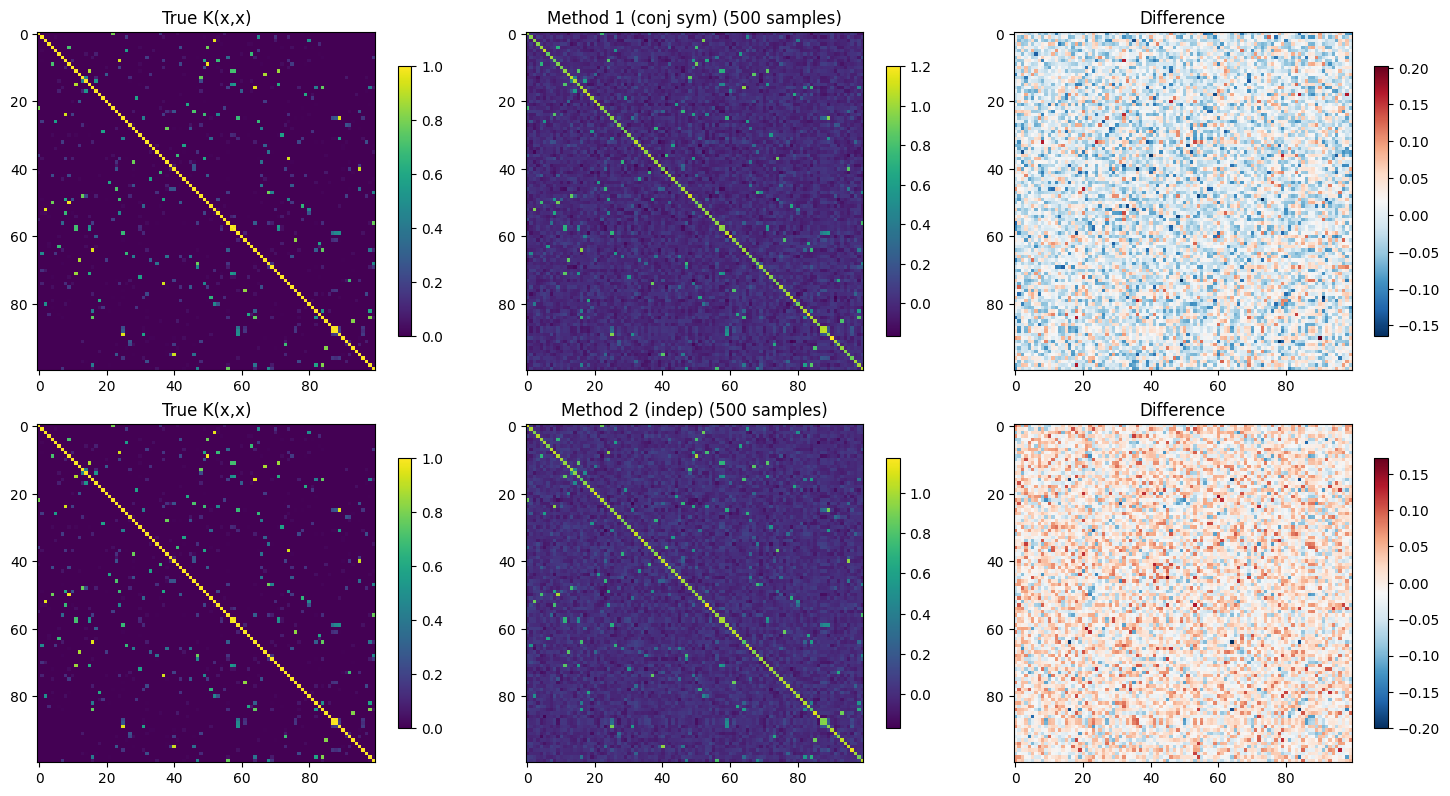

Method 1: rel Frob err = 0.3426, diag mean = 0.9975 (should be ~1)
Method 2: rel Frob err = 0.3326, diag mean = 0.9927 (should be ~1)


In [375]:
import matplotlib.pyplot as plt
import numpy as np

def sample_conjugate_symmetric_z(M, mtot, d, cdtype, rdtype, device):
    """Draw z with Z_{-j} = conj(Z_j), E[|Z_j|^2]=1."""
    indices = torch.arange(M)
    remaining = indices.clone()
    conj_flat = torch.zeros(M, dtype=torch.long)
    for dim in range(d):
        stride = mtot ** (d - 1 - dim)
        mi = remaining // stride
        remaining = remaining % stride
        conj_flat += (mtot - 1 - mi) * stride
    is_self_conj = (indices == conj_flat)
    is_primary = indices < conj_flat
    z = torch.zeros(M, dtype=cdtype, device=device)
    z_real = torch.randn(M, device=device, dtype=rdtype)
    z_imag = torch.randn(M, device=device, dtype=rdtype)
    z[is_self_conj] = z_real[is_self_conj].to(cdtype)
    z[is_primary] = ((z_real[is_primary] + 1j * z_imag[is_primary]) / (2**0.5)).to(cdtype)
    z[~is_primary & ~is_self_conj] = z[conj_flat[~is_primary & ~is_self_conj]].conj()
    return z

def sample_independent_z(M, cdtype, rdtype, device):
    """Draw i.i.d. z ~ CN(0,1)."""
    z_real = torch.randn(M, device=device, dtype=rdtype)
    z_imag = torch.randn(M, device=device, dtype=rdtype)
    return ((z_real + 1j * z_imag) / (2**0.5)).to(cdtype)

# --- Covariance diagnostic for both methods ---
n_samples = 500
M = len(ws)

samples_m1, samples_m2 = [], []
for _ in range(n_samples):
    z1 = sample_conjugate_symmetric_z(M, mtot, d, cdtype, rdtype, device)
    samples_m1.append(fwd(ws * z1).real)
    z2s = sample_independent_z(M, cdtype, rdtype, device)
    samples_m2.append((2**0.5) * fwd(ws * z2s).real)

samples_m1 = torch.stack(samples_m1, dim=0)
samples_m2 = torch.stack(samples_m2, dim=0)
cov_m1 = (samples_m1.T @ samples_m1) / n_samples
cov_m2 = (samples_m2.T @ samples_m2) / n_samples

# True covariance
dists_sq = torch.cdist(x, x).pow(2)
cov_true = variance * torch.exp(-0.5 * dists_sq / lengthscale**2)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, (cov_emp, label) in enumerate([(cov_m1, 'Method 1 (conj sym)'), (cov_m2, 'Method 2 (indep)')]):
    im0 = axes[row,0].imshow(cov_true.numpy(), cmap='viridis')
    axes[row,0].set_title('True K(x,x)')
    plt.colorbar(im0, ax=axes[row,0], shrink=0.8)
    im1 = axes[row,1].imshow(cov_emp.numpy(), cmap='viridis')
    axes[row,1].set_title(f'{label} ({n_samples} samples)')
    plt.colorbar(im1, ax=axes[row,1], shrink=0.8)
    im2 = axes[row,2].imshow((cov_emp - cov_true).numpy(), cmap='RdBu_r')
    axes[row,2].set_title('Difference')
    plt.colorbar(im2, ax=axes[row,2], shrink=0.8)

plt.tight_layout()
plt.show()

for cov_emp, label in [(cov_m1, 'Method 1'), (cov_m2, 'Method 2')]:
    rel_err = torch.norm(cov_emp - cov_true) / torch.norm(cov_true)
    print(f'{label}: rel Frob err = {rel_err:.4f}, diag mean = {cov_emp.diag().mean():.4f} (should be ~{variance})')